In [5]:
import pandas as pd

In [6]:
dtf = pd.read_csv('http://bit.ly/kaggletrain')
dtf.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


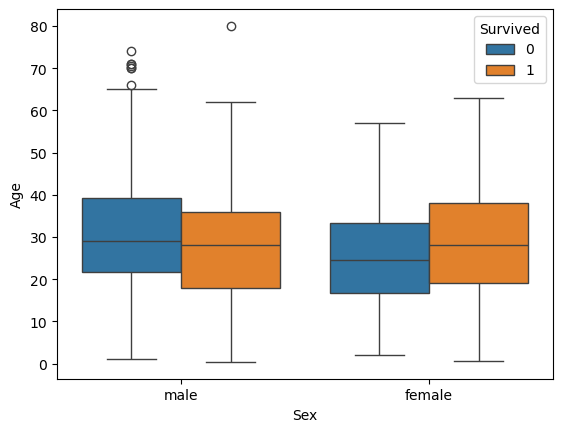

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=dtf, x="Sex", y="Age", hue="Survived")
plt.show()

In [1]:
import io
import contextlib

def code_exec(code: str) -> str:
    output = io.StringIO()
    with contextlib.redirect_stdout(output):
        try:
            exec(code)
        except Exception as e:
            print(f"Error: {e}")
    return output.getvalue()

tool_code_exec = {'type': 'function', 'function':{
    'name': 'code_exec',
    'description': 'execute python code',
    'parameters': {'type': 'object',
                   'required': ['code'],
                   'properties': {
                       'code': {'type': 'str', 'description': 'code to execute'},
}}}}

code_exec("a=1+1; print(a)")

'2\n'

📁 Provide a CSV path > http://bit.ly/kaggletrain


🔧 > code_exec -> Inputs: {'code': 'import pandas as pd; df=pd.read_csv("http://bit.ly/kaggletrain"); print(df.head())'}
👽 >    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250  

🙂 > create a boxplot with the columns 'Sex' and 'Age' and use the column 'Survived' for color.


🔧 > code_exec -> Inputs: {'code': 'import seaborn as sns; import matplotlib.pyplot as plt; import pandas as pd; df = pd.read_csv("http://bit.ly/kaggletrain"); g = sns.boxplot(x=df[\'Sex\'], y=df[\'Age\'], hue=df[\'Survived\']); g.legend(title=\'Survived\'); plt.show()'}


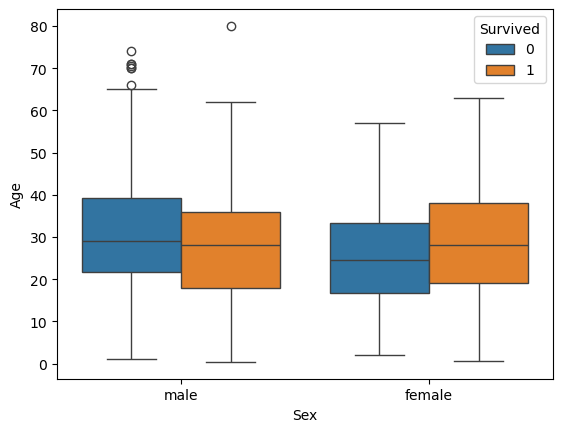

👽 > 


🙂 > quit


In [4]:
import ollama
# llm = "llama3.1"
llm = "qwen2.5"

prompt = '''You are an expert data scientist, and you have tools to execute python code.
First of all, use the tool to execute the following code exactly like this: 'df=pd.read_csv(path); print(df.head())'
Right after you use the tool to generate code, you MUST ALWAYS use also the tool to execute the code you generated.
'''

messages = [{"role":"system", "content":prompt}]
memory = '''Use the dataframe 'df'.'''
start = True

while True:
    ## user input
    try:
        if start is True:
            path = input('📁 Provide a CSV path >')
            q = "path = "+path
        else:
            q = input('🙂 >')
    except EOFError:
        break

    if q == "quit":
        break
    if q.strip() == "":
        continue

    ## memory
    if start is False:
        q = memory+"\n"+q
    messages.append( {"role":"user", "content":q} )

    ## model
    agent_res = ollama.chat(
        model=llm,
        #format="json", #or schema
        stream=False,
        tools=[tool_code_exec],
        messages=messages)

    ## response
    dic_tools = {'code_exec':code_exec}

    if "tool_calls" in dir( agent_res["message"] ):
        for tool in agent_res["message"]["tool_calls"]:
            
            t_name, t_inputs = tool["function"]["name"], tool["function"]["arguments"]
            
            if f := dic_tools.get(t_name):
                ### calling tool
                print('🔧 >', f"\x1b[1;31m{t_name} -> Inputs: {t_inputs}\x1b[0m")
                messages.append( {"role":"user", "content":"use toll'"+t_name+"' with inputs: "+str(t_inputs)} )

                ### tool output
                t_output = f(**tool["function"]["arguments"])

                ### final res
                res = t_output
            else:
                print('🤬 >', f"\x1b[1;31m{t_name} -> NotFound\x1b[0m")

    if agent_res['message']['content'] != '':
        res = agent_res["message"]["content"]

    print("👽 >", f"\x1b[1;30m{res}\x1b[0m")
    messages.append( {"role":"assistant", "content":res} )
    start = False

In [5]:
messages

[{'role': 'system',
  'content': "You are an expert data scientist, and you have tools to execute python code.\nFirst of all, use the tool to execute the following code exactly like this: 'df=pd.read_csv(path); print(df.head())'\nRight after you use the tool to generate code, you MUST ALWAYS use also the tool to execute the code you generated.\n"},
 {'role': 'user', 'content': 'path = http://bit.ly/kaggletrain'},
 {'role': 'user',
  'content': 'use toll\'code_exec\' with inputs: {\'code\': \'import pandas as pd; df=pd.read_csv("http://bit.ly/kaggletrain"); print(df.head())\'}'},
 {'role': 'assistant',
  'content': '   PassengerId  Survived  Pclass  \\\n0            1         0       3   \n1            2         1       1   \n2            3         1       3   \n3            4         1       1   \n4            5         0       3   \n\n                                                Name     Sex   Age  SibSp  \\\n0                            Braund, Mr. Owen Harris    male  22.0      1